### Imports and Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Data Ingestion and Cleaning

### Load accelerometer file

In [2]:
COLS = [
    "device_ts",
    "phone_ts",
    "datetime",
    "device",
    "value"
]

def load_accel_file(path, axis_name):
    df = pd.read_csv(
        path,
        header=None,
        names=COLS
    )
    df["axis"] = axis_name
    df["phone_ts"] = df["phone_ts"].astype(np.int64)
    df["value"] = df["value"].astype(float)
    return df


### Load and merge X / Y / Z

In [3]:
ax = load_accel_file("Nail_2_Accelerometer_x.txt", "ax")
ay = load_accel_file("Nail_2_Accelerometer_y.txt", "ay")
az = load_accel_file("Nail_2_Accelerometer_z.txt", "az")

# Pivot to wide format
df = (
    pd.concat([ax, ay, az])
    .pivot_table(
        index="phone_ts",
        columns="axis",
        values="value"
    )
    .reset_index()
    .sort_values("phone_ts")
)

df.head()


axis,phone_ts,ax,ay,az
0,1772497116118,0.98,-0.44,10.13
1,1772497116128,1.05,-0.41,10.28
2,1772497116138,1.09,-0.19,10.16
3,1772497116148,1.23,-0.48,10.08
4,1772497116158,1.82,-0.86,10.42


### Sampling rate & data quality check

In [4]:
df["dt_ms"] = df["phone_ts"].diff()

median_dt = df["dt_ms"].median()
fs = 1000 / median_dt

print(f"Median dt: {median_dt:.2f} ms")
print(f"Estimated fs: {fs:.1f} Hz")

print("Large gaps (>30 ms):")
print((df["dt_ms"] > 30).sum())


Median dt: 10.00 ms
Estimated fs: 100.0 Hz
Large gaps (>30 ms):
1


### Add magnitude

In [5]:
df["a_mag"] = np.sqrt(
    df["ax"]**2 + df["ay"]**2 + df["az"]**2
)

df.head()

axis,phone_ts,ax,ay,az,dt_ms,a_mag
0,1772497116118,0.98,-0.44,10.13,NaN,10.186800
1,1772497116128,1.05,-0.41,10.28,10.0,10.341615
2,1772497116138,1.09,-0.19,10.16,10.0,10.220068
3,1772497116148,1.23,-0.48,10.08,10.0,10.166105
4,1772497116158,1.82,-0.86,10.42,10.0,10.612653


### Quick sanity plot

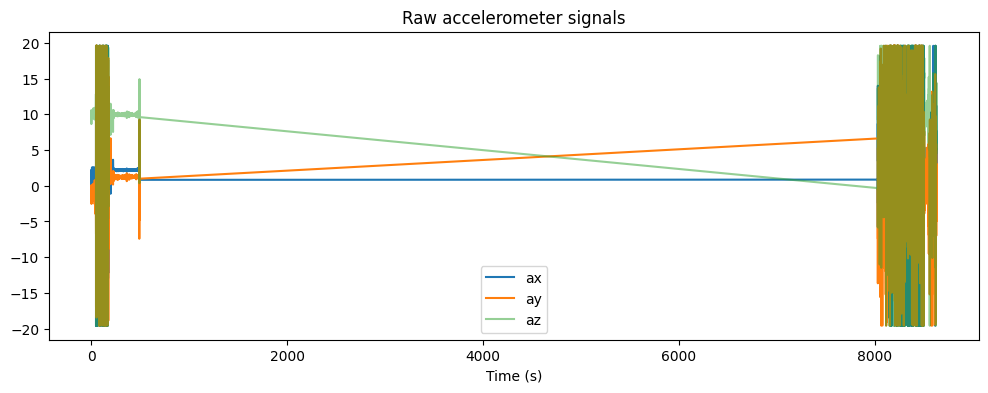

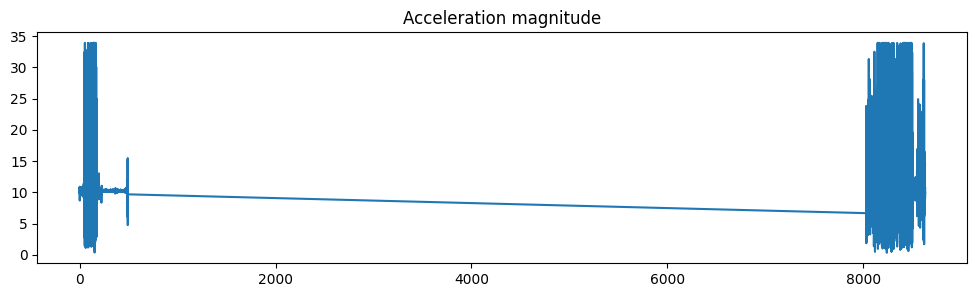

In [6]:
t = (df["phone_ts"] - df["phone_ts"].iloc[0]) / 1000.0

plt.figure(figsize=(12,4))
plt.plot(t, df["ax"], label="ax")
plt.plot(t, df["ay"], label="ay")
plt.plot(t, df["az"], label="az", alpha=0.5)
plt.legend()
plt.xlabel("Time (s)")
plt.title("Raw accelerometer signals")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(t, df["a_mag"], label="|a|")
plt.title("Acceleration magnitude")
plt.show()


### Load and Parse Logger

In [7]:
logger_cols = ["phone_ts", "datetime", "label"]

log = pd.read_csv(
    "activity_log.txt",
    header=None,
    names=logger_cols
)

log["phone_ts"] = log["phone_ts"].astype(np.int64)
log["label"] = log["label"].str.strip()

log


,phone_ts,datetime,label
0,1772497163293,2026-03-02 16:19:23,stap
1,1772497183468,2026-03-02 16:19:43,etap
2,1772497194578,2026-03-02 16:19:54,stap
3,1772497218805,2026-03-02 16:20:18,etap
4,1772497225412,2026-03-02 16:20:25,stap
5,1772497246877,2026-03-02 16:20:46,etap
6,1772497252625,2026-03-02 16:20:52,stap
7,1772497278995,2026-03-02 16:21:18,etap
8,1772505259631,2026-03-02 18:34:19,stap
9,1772505292943,2026-03-02 18:34:52,etap


# Gesture Extraction

### Build gesture intervals from stap / etap

In [8]:
START_TAG = "stap"
END_TAG   = "etap"

def build_intervals(log_df, start_tag=START_TAG, end_tag=END_TAG):
    """
    Convert start/end event log into intervals.
    Returns:
      intervals_df: columns [gesture, start_ts, end_ts, duration_ms]
      issues: list of warnings about mismatches
    """
    log_df = log_df.copy().sort_values("phone_ts").reset_index(drop=True)
    issues = []
    stack = []  # store start timestamps

    intervals = []
    for i, row in log_df.iterrows():
        label = str(row["label"]).strip().lower()
        t = int(row["phone_ts"])

        if label == start_tag.lower():
            stack.append(t)

        elif label == end_tag.lower():
            if len(stack) == 0:
                issues.append(f"END without START at i={i}, ts={t}")
                continue
            start_ts = stack.pop(0)  # FIFO pairing (most common in gesture protocols)
            end_ts = t
            if end_ts <= start_ts:
                issues.append(f"Non-positive duration interval: start={start_ts}, end={end_ts}")
                continue

            intervals.append({
                "gesture": "tap",
                "start_ts": start_ts,
                "end_ts": end_ts,
                "duration_ms": end_ts - start_ts
            })

        else:
            # ignore other tags for now
            pass

    if len(stack) > 0:
        issues.append(f"{len(stack)} START events never closed with END.")

    intervals_df = pd.DataFrame(intervals).sort_values("start_ts").reset_index(drop=True)
    return intervals_df, issues


intervals, issues = build_intervals(log, START_TAG, END_TAG)
print(intervals.head())
print("\nIssues:")
for w in issues[:10]:
    print(" -", w)


  gesture       start_ts         end_ts  duration_ms
0     tap  1772497163293  1772497183468        20175
1     tap  1772497194578  1772497218805        24227
2     tap  1772497225412  1772497246877        21465
3     tap  1772497252625  1772497278995        26370
4     tap  1772505259631  1772505292943        33312

Issues:


### Plot accel signals for these tap intervals

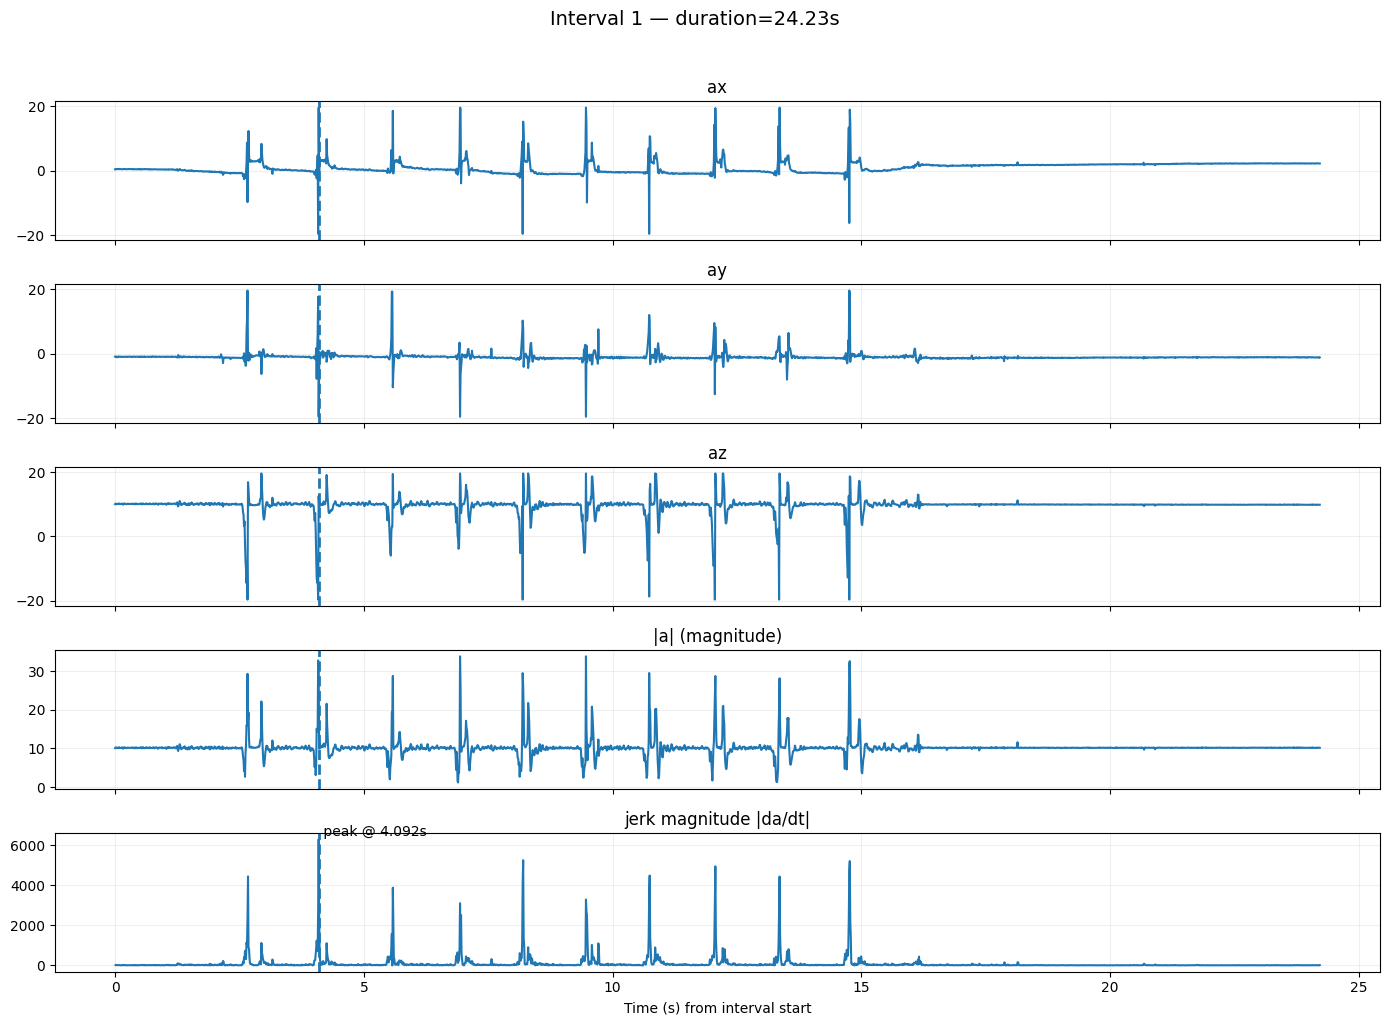

Peak jerk time: 4.092 s into interval


In [9]:
def compute_jerk(seg):
    """
    seg must contain phone_ts, ax, ay, az
    returns: t_jerk (seconds from seg start), jerk_mag
    """
    seg = seg.sort_values("phone_ts")
    t_ms = seg["phone_ts"].to_numpy().astype(np.float64)
    t_s = (t_ms - t_ms[0]) / 1000.0

    ax = seg["ax"].to_numpy()
    ay = seg["ay"].to_numpy()
    az = seg["az"].to_numpy()

    dt = np.diff(t_ms) / 1000.0
    dt[dt == 0] = np.nan

    dax = np.diff(ax) / dt
    day = np.diff(ay) / dt
    daz = np.diff(az) / dt

    jerk = np.sqrt(dax**2 + day**2 + daz**2)
    t_jerk = t_s[1:]  # aligns with diff

    return t_s, t_jerk, jerk

def plot_interval_separate(df, start_ts, end_ts, title="", max_points=8000, show_peak=True):
    seg = df[(df["phone_ts"] >= start_ts) & (df["phone_ts"] <= end_ts)].copy()
    if len(seg) == 0:
        print("No data in interval:", start_ts, end_ts)
        return None

    seg = seg.sort_values("phone_ts")

    # Downsample ONLY for plotting (keeps plots responsive).
    if len(seg) > max_points:
        idx = np.linspace(0, len(seg) - 1, max_points).astype(int)
        seg_plot = seg.iloc[idx].copy()
    else:
        seg_plot = seg

    # Time axes
    t_plot = (seg_plot["phone_ts"].to_numpy() - seg_plot["phone_ts"].iloc[0]) / 1000.0

    # Jerk computed on the FULL segment (not downsampled) for correctness
    t_full, t_jerk, jerk = compute_jerk(seg)

    peak_t = None
    if np.isfinite(jerk).any():
        peak_idx = np.nanargmax(jerk)
        peak_t = float(t_jerk[peak_idx])

    # Make sure magnitude exists
    if "a_mag" not in seg_plot.columns:
        seg_plot["a_mag"] = np.sqrt(seg_plot["ax"]**2 + seg_plot["ay"]**2 + seg_plot["az"]**2)

    fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(t_plot, seg_plot["ax"])
    axes[0].set_title("ax")

    axes[1].plot(t_plot, seg_plot["ay"])
    axes[1].set_title("ay")

    axes[2].plot(t_plot, seg_plot["az"])
    axes[2].set_title("az")

    axes[3].plot(t_plot, seg_plot["a_mag"])
    axes[3].set_title("|a| (magnitude)")

    axes[4].plot(t_jerk, jerk)
    axes[4].set_title("jerk magnitude |da/dt|")

    if show_peak and peak_t is not None:
        for ax_ in axes:
            ax_.axvline(peak_t, linestyle="--", linewidth=2)
        axes[4].text(peak_t, np.nanmax(jerk), f" peak @ {peak_t:.3f}s", va="bottom")

    for ax_ in axes:
        ax_.grid(True, alpha=0.2)

    axes[-1].set_xlabel("Time (s) from interval start")

    fig.suptitle(
        title if title else f"Interval {start_ts} → {end_ts} (n={len(seg)})",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    if peak_t is not None:
        print(f"Peak jerk time: {peak_t:.3f} s into interval")

    return seg, peak_t


i = 1  # your example interval index
row = intervals.iloc[i]

seg, peak_t = plot_interval_separate(
    df,
    row["start_ts"],
    row["end_ts"],
    title=f"Interval {i} — duration={row['duration_ms']/1000:.2f}s",
    max_points=8000,
    show_peak=True
)


### Auto-trim true tap segment from long interval

We will:

- Find peak jerk time inside each interval

- Extract a fixed ±W ms window around that time

- Store these as clean tap segments

Estimated fs: 100.0
Detected peaks: 12 | dbg: {'thr': np.float64(78.22426960870476), 'num_regions': 18, 'num_candidates': 18, 'num_peaks': 12}


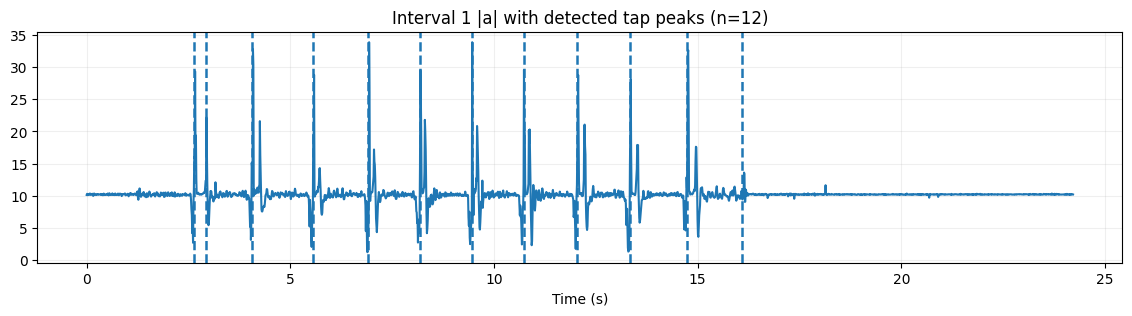

Peak times (s into interval): [np.float64(2.642), np.float64(2.941), np.float64(4.062), np.float64(5.553), np.float64(6.914), np.float64(8.183), np.float64(9.465), np.float64(10.726), np.float64(12.046), np.float64(13.337), np.float64(14.748), np.float64(16.098)]


In [10]:
def median_smooth(x, k=9):
    """
    Simple median smoothing with odd window size k.
    """
    k = int(k)
    if k < 3:
        return x
    if k % 2 == 0:
        k += 1
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    out = np.empty_like(x)
    for i in range(len(x)):
        out[i] = np.median(xp[i:i+k])
    return out


def find_tap_peaks_in_interval(seg, fs=100.0, smooth_k=9,
                               thr_mult=6.0,
                               min_dur_ms=40, max_dur_ms=500,
                               min_gap_ms=250):
    """
    Returns a list of peak timestamps (epoch ms), one per detected tap-like cluster.
    """
    seg = seg.sort_values("phone_ts")
    t_ms = seg["phone_ts"].to_numpy().astype(np.float64)
    t_s  = (t_ms - t_ms[0]) / 1000.0

    ax = seg["ax"].to_numpy()
    ay = seg["ay"].to_numpy()
    az = seg["az"].to_numpy()

    dt = np.diff(t_ms) / 1000.0
    dt[dt == 0] = np.nan

    dax = np.diff(ax) / dt
    day = np.diff(ay) / dt
    daz = np.diff(az) / dt
    jerk = np.sqrt(dax**2 + day**2 + daz**2)
    t_jerk = t_s[1:]  # aligns with jerk

    jerk_s = median_smooth(jerk, k=smooth_k)

    # robust threshold
    med = np.nanmedian(jerk_s)
    mad = np.nanmedian(np.abs(jerk_s - med)) + 1e-9
    thr = med + thr_mult * mad
    mask = jerk_s > thr

    # contiguous regions
    regions = []
    i = 0
    n = len(mask)
    while i < n:
        if not mask[i]:
            i += 1
            continue
        j = i
        while j < n and mask[j]:
            j += 1
        regions.append((i, j))
        i = j

    # duration bounds in samples
    min_len = max(2, int((min_dur_ms/1000.0) * fs))
    max_len = max(min_len+1, int((max_dur_ms/1000.0) * fs))

    candidates = []
    for (a, b) in regions:
        L = b - a
        if L < min_len or L > max_len:
            continue

        # peak within region
        local_idx = int(np.nanargmax(jerk_s[a:b]))
        idx = a + local_idx

        peak_ts = int(t_ms[idx + 1])  # +1 because diff
        peak_val = float(jerk_s[idx])
        area = float(np.nansum(jerk_s[a:b]))

        candidates.append((peak_ts, peak_val, area, a, b))

    # sort by time
    candidates.sort(key=lambda x: x[0])

    # enforce min gap between peaks (avoid double-counting rebound)
    filtered = []
    last_ts = None
    for (ts, peak_val, area, a, b) in candidates:
        if last_ts is None or (ts - last_ts) >= min_gap_ms:
            filtered.append((ts, peak_val, area))
            last_ts = ts
        else:
            # if two are too close, keep the stronger one
            if peak_val > filtered[-1][1]:
                filtered[-1] = (ts, peak_val, area)
                last_ts = ts

    peak_ts_list = [x[0] for x in filtered]
    debug = {"thr": thr, "num_regions": len(regions), "num_candidates": len(candidates), "num_peaks": len(peak_ts_list)}
    return peak_ts_list, debug




# --- Multi-peak debug for one interval i ---

i = 1
row = intervals.iloc[i]
seg_long = df[(df["phone_ts"] >= row["start_ts"]) & (df["phone_ts"] <= row["end_ts"])].copy()

dt_ms = seg_long["phone_ts"].sort_values().diff().median()
fs_est = 1000.0 / dt_ms if pd.notnull(dt_ms) and dt_ms > 0 else 100.0
print("Estimated fs:", fs_est)

peak_ts_list, dbg = find_tap_peaks_in_interval(seg_long, fs=fs_est)
print("Detected peaks:", len(peak_ts_list), "| dbg:", dbg)

# Plot |a| with vertical lines for each detected peak
seg_long = seg_long.sort_values("phone_ts")
t0_ms = seg_long["phone_ts"].iloc[0]
t = (seg_long["phone_ts"] - t0_ms) / 1000.0

plt.figure(figsize=(14,3))
plt.plot(t, seg_long["a_mag"])
for k, ts in enumerate(peak_ts_list):
    peak_t = (ts - t0_ms) / 1000.0
    plt.axvline(peak_t, linestyle="--", linewidth=1.8)
plt.title(f"Interval {i} |a| with detected tap peaks (n={len(peak_ts_list)})")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.2)
plt.show()

# (Optional) print peak times in seconds
print("Peak times (s into interval):", [round((ts - t0_ms)/1000.0, 3) for ts in peak_ts_list])


### Trim final tap segments (±250 ms)

For finger tap:

- contact + rebound ≈ 100–200 ms

- add buffer → ±250 ms is safe

- So each segment ≈ 500 ms @ 100 Hz ≈ 50 samples.

In [11]:
FINAL_HALF_WINDOW_MS = 250
final_tap_segments = []

for interval_idx, row in intervals.iterrows():
    seg_long = df[
        (df["phone_ts"] >= row["start_ts"]) &
        (df["phone_ts"] <= row["end_ts"])
    ].copy()

    if len(seg_long) < 20:
        continue

    dt_ms = seg_long["phone_ts"].sort_values().diff().median()
    fs_est = 1000.0 / dt_ms if pd.notnull(dt_ms) and dt_ms > 0 else 100.0

    peak_ts_list, dbg = find_tap_peaks_in_interval(seg_long, fs=fs_est)

    print(f"Interval {interval_idx}: detected {len(peak_ts_list)} tap peaks | dbg={dbg}")

    for peak_ts in peak_ts_list:
        t0 = peak_ts - FINAL_HALF_WINDOW_MS
        t1 = peak_ts + FINAL_HALF_WINDOW_MS

        seg_final = df[
            (df["phone_ts"] >= t0) &
            (df["phone_ts"] <= t1)
        ].copy()

        if len(seg_final) < 10:
            continue

        final_tap_segments.append({
            "interval_idx": interval_idx,
            "peak_ts": peak_ts,
            "segment": seg_final
        })

print("Total tap segments extracted:", len(final_tap_segments))


Interval 0: detected 16 tap peaks | dbg={'thr': np.float64(91.82510192295126), 'num_regions': 20, 'num_candidates': 19, 'num_peaks': 16}
Interval 1: detected 12 tap peaks | dbg={'thr': np.float64(78.22426960870476), 'num_regions': 18, 'num_candidates': 18, 'num_peaks': 12}
Interval 2: detected 8 tap peaks | dbg={'thr': np.float64(16.97190872521856), 'num_regions': 11, 'num_candidates': 9, 'num_peaks': 8}
Interval 3: detected 22 tap peaks | dbg={'thr': np.float64(47.06805748539898), 'num_regions': 28, 'num_candidates': 25, 'num_peaks': 22}
Interval 4: detected 20 tap peaks | dbg={'thr': np.float64(41.58832111043907), 'num_regions': 30, 'num_candidates': 24, 'num_peaks': 20}
Interval 5: detected 24 tap peaks | dbg={'thr': np.float64(48.354464125544794), 'num_regions': 31, 'num_candidates': 26, 'num_peaks': 24}
Interval 6: detected 18 tap peaks | dbg={'thr': np.float64(45.74222679962409), 'num_regions': 27, 'num_candidates': 20, 'num_peaks': 18}
Interval 7: detected 8 tap peaks | dbg={'th

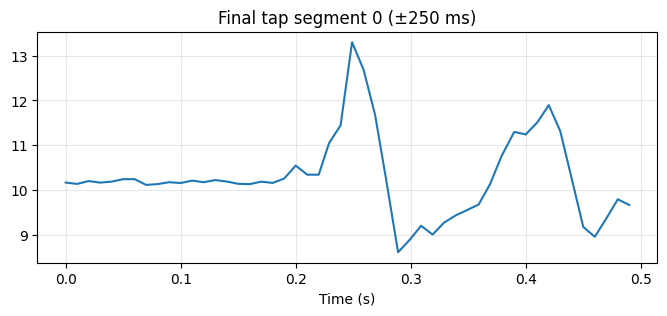

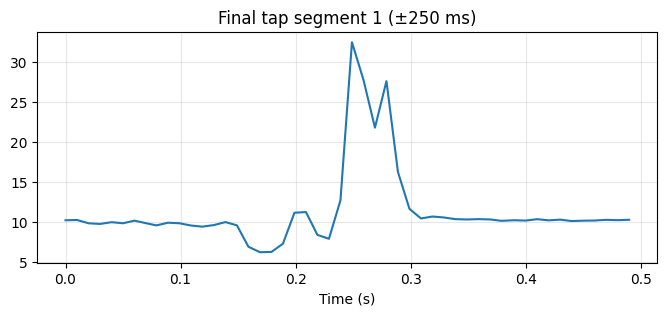

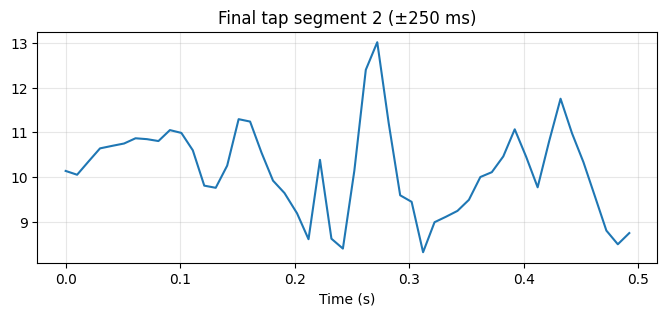

In [12]:
def plot_final_tap(seg, title=""):
    t = (seg["phone_ts"] - seg["phone_ts"].iloc[0]) / 1000.0
    plt.figure(figsize=(8,3))
    plt.plot(t, seg["a_mag"])
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

for i in range(min(3, len(final_tap_segments))):
    plot_final_tap(
        final_tap_segments[i]["segment"],
        title=f"Final tap segment {i} (±{FINAL_HALF_WINDOW_MS} ms)"
    )


### Generate negative (non-tap) segments

We now need examples of “not a tap” that:

- have the same duration (±250 ms → ~500 ms total)

- do not overlap any tap window

- come from the same recording distribution (same sensor, same session)

In [13]:
  # Compute peak |a| for each tap
tap_peaks = []
for item in final_tap_segments:
    seg = item["segment"]
    tap_peaks.append(seg["a_mag"].max())

tap_peaks = np.array(tap_peaks)

print("Tap peak |a| stats:")
print("  min :", tap_peaks.min())
print("  median:", np.median(tap_peaks))
print("  max :", tap_peaks.max())


# --- Robust negative filtering (Stage 1) ---

NEG_PEAK_FRAC = 0.5  # keep negatives below 50% of a robust "weak tap" reference

# 1) Compute tap peaks
tap_peaks = np.array([item["segment"]["a_mag"].max() for item in final_tap_segments])

# 2) Drop junk/false-positive taps using a robust lower bound (p5)
tap_qc_threshold = np.percentile(tap_peaks, 5)

good_final_tap_segments = []
good_tap_peaks = []

for item, peak in zip(final_tap_segments, tap_peaks):
    if peak >= tap_qc_threshold:
        good_final_tap_segments.append(item)
        good_tap_peaks.append(peak)

good_tap_peaks = np.array(good_tap_peaks)

print("Tap QC threshold (p5):", tap_qc_threshold)
print("Original taps:", len(final_tap_segments))
print("Good taps:", len(good_final_tap_segments))
print("Dropped taps:", len(final_tap_segments) - len(good_final_tap_segments))


Tap peak |a| stats:
  min : 10.349483078878867
  median: 20.730308333922473
  max : 33.94242330771332
Tap QC threshold (p5): 10.575876792224676
Original taps: 268
Good taps: 254
Dropped taps: 14


In [14]:
# --- NEW: sample negatives only from still tail after last etap ---

MARGIN_MS = 1000  # skip 1s after last etap
NEG_HALF_WINDOW_MS = FINAL_HALF_WINDOW_MS

# Build forbidden intervals around each tap peak (use GOOD taps)
FORBID_PAD_MS = FINAL_HALF_WINDOW_MS + 50

forbidden = []
for item in good_final_tap_segments:
    t = item["peak_ts"]
    forbidden.append((t - FORBID_PAD_MS, t + FORBID_PAD_MS))
forbidden = np.array(forbidden)

def overlaps_forbidden(t0, t1, forbidden_intervals):
    return np.any((t0 <= forbidden_intervals[:,1]) & (t1 >= forbidden_intervals[:,0]))

# Define still window: after last etap
last_etap_ts = log.loc[log["label"].str.strip().str.lower() == END_TAG, "phone_ts"].max()


# --- Robust: find last continuous block in df by looking for big timestamp gaps ---

GAP_MS = 30_000  # 30s gap = new session boundary (tune if needed)

ts_sorted = df["phone_ts"].sort_values().to_numpy()
gaps = np.diff(ts_sorted)

# indices where a big gap happens
breaks = np.where(gaps > GAP_MS)[0]

if len(breaks) == 0:
    # one continuous session
    session_start = int(ts_sorted[0])
else:
    # last session starts right after the last big gap
    session_start = int(ts_sorted[breaks[-1] + 1])

session_end = int(ts_sorted[-1])

print("Last session duration (s):", (session_end - session_start)/1000)

# Now define still tail as: after last etap, but clipped to last session
t_still_start = max(int(last_etap_ts + MARGIN_MS), session_start)
t_still_end = session_end

print("Still window duration (s):", (t_still_end - t_still_start) / 1000)

rng = np.random.default_rng(42)

def sample_negatives_from_range(df, forbidden, start_ts, end_ts, n_samples, half_window_ms):
    negs = []
    tries = 0
    max_tries = n_samples * 500

    while len(negs) < n_samples and tries < max_tries:
        tries += 1
        center = int(rng.integers(start_ts + half_window_ms, end_ts - half_window_ms))
        t0 = center - half_window_ms
        t1 = center + half_window_ms

        if overlaps_forbidden(t0, t1, forbidden):
            continue

        seg = df[(df["phone_ts"] >= t0) & (df["phone_ts"] <= t1)].copy()
        if len(seg) < 10:
            continue

        negs.append({"center_ts": center, "segment": seg})

    return negs

# Sample as many negatives as good taps (or more, if you want)
target_n = len(good_final_tap_segments)
neg_segments = sample_negatives_from_range(
    df, forbidden, t_still_start, t_still_end, n_samples=target_n, half_window_ms=NEG_HALF_WINDOW_MS
)

print("Negatives sampled from still tail:", len(neg_segments))


Last session duration (s): 601.386
Still window duration (s): 129.852
Negatives sampled from still tail: 254


### Filter bad negatives:

In [15]:
# 3) Define robust weak-tap reference using p10 of good taps
tap_ref = np.percentile(good_tap_peaks, 10)
neg_peak_threshold = NEG_PEAK_FRAC * tap_ref

print("Tap reference (p10 of good taps):", tap_ref)
print("Negative peak threshold:", neg_peak_threshold)

# 4) Filter negatives
# 4) Filter negatives (ROBUST): use 95th percentile instead of max
# Compute jerk scale from GOOD taps
tap_jerk_peaks = []

for item in good_final_tap_segments:
    seg = item["segment"].sort_values("phone_ts")
    _, _, jerk = compute_jerk(seg)
    tap_jerk_peaks.append(np.nanmax(jerk))

tap_jerk_peaks = np.array(tap_jerk_peaks)

print("Tap jerk stats:")
print("  min:", tap_jerk_peaks.min())
print("  p10:", np.percentile(tap_jerk_peaks, 10))
print("  median:", np.median(tap_jerk_peaks))
print("  max:", tap_jerk_peaks.max())

NEG_JERK_FRAC = 0.4  # keep negatives below 40% of weak tap jerk
NEG_JERK_Q = 95     # robust to spikes

jerk_ref = np.percentile(tap_jerk_peaks, 10)
jerk_threshold = NEG_JERK_FRAC * jerk_ref

print("Jerk reference (p10 tap):", jerk_ref)
print("Negative jerk threshold:", jerk_threshold)

clean_neg_segments = []
rejected_neg_segments = []

for item in neg_segments:
    seg = item["segment"].sort_values("phone_ts")
    _, _, jerk = compute_jerk(seg)
    q = np.nanpercentile(jerk, NEG_JERK_Q)
    if q < jerk_threshold:
        clean_neg_segments.append(item)
    else:
        rejected_neg_segments.append(item)

print("Original negatives:", len(neg_segments))
print("Clean negatives:", len(clean_neg_segments))
print("Rejected negatives:", len(rejected_neg_segments))


Tap reference (p10 of good taps): 11.023329347427138
Negative peak threshold: 5.511664673713569
Tap jerk stats:
  min: 87.1665073293636
  p10: 202.50104471148833
  median: 2465.8743467108684
  max: 6785.597762909322
Jerk reference (p10 tap): 202.50104471148833
Negative jerk threshold: 81.00041788459534
Original negatives: 254
Clean negatives: 157
Rejected negatives: 97


# Baseline Models



In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf

### Build X/y from (good taps + clean negatives) with leakage-resistant groups

In [17]:

# --- Config ---
N_SAMPLES = 64
CHANNELS = ["ax", "ay", "az", "a_mag", "jerk"]

def compute_jerk_channel(seg):
    seg = seg.sort_values("phone_ts")
    t = seg["phone_ts"].to_numpy().astype(float) / 1000.0  # seconds
    ax = seg["ax"].to_numpy()
    ay = seg["ay"].to_numpy()
    az = seg["az"].to_numpy()

    dt = np.diff(t)
    dt[dt == 0] = np.nan

    dax = np.diff(ax) / dt
    day = np.diff(ay) / dt
    daz = np.diff(az) / dt

    jerk = np.sqrt(dax**2 + day**2 + daz**2)

    # pad to match length
    jerk = np.concatenate([[jerk[0]], jerk])
    return jerk


def resample_segment(seg, n=64):
    seg = seg.sort_values("phone_ts")

    t = seg["phone_ts"].to_numpy().astype(float)
    t = (t - t[0]) / (t[-1] - t[0] + 1e-9)
    t_new = np.linspace(0, 1, n)

    X = []

    for ch in ["ax", "ay", "az", "a_mag"]:
        y = seg[ch].to_numpy().astype(float)
        X.append(np.interp(t_new, t, y))

    jerk = compute_jerk_channel(seg)
    X.append(np.interp(t_new, t, jerk))

    return np.stack(X, axis=1)  # (64, 5)


# --- Per-segment normalization ---
def zscore_per_segment(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd

# --- Build dataset with groups to avoid leakage ---
X_list, y_list, g_list = [], [], []

# Positives: use QC-passed taps; group by burst interval_idx
for item in good_final_tap_segments:
    seg = item["segment"]
    X = zscore_per_segment(resample_segment(seg))
    X_list.append(X)
    y_list.append(1)
    g_list.append(int(item["interval_idx"]))

# Negatives: group by coarse time buckets to avoid near-duplicate still windows leaking
BUCKET_MS = 10_000  # 10 seconds (tune later: 5–30s)

# INCLUDES hard negatives, remove "rejected_neg_segments" for only clean
for item in (clean_neg_segments + rejected_neg_segments):
    seg = item["segment"]
    X = zscore_per_segment(resample_segment(seg))
    X_list.append(X)
    y_list.append(0)
    g_list.append(int(item["center_ts"] // BUCKET_MS) + 1_000_000)  # separate id space

X = np.stack(X_list)                 # (N, 64, 4)
y = np.array(y_list).astype(int)
groups = np.array(g_list).astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (508, 64, 5)
y shape: (508,)


### Train the first baseline: LogReg

In [18]:

# 1) Sanity checks (allow variable #channels)
assert X.ndim == 3 and X.shape[1] == 64, f"Unexpected X shape: {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Mismatch: len(y)={len(y)} len(X)={len(X)}"
assert "groups" in globals(), "groups not found. Rebuild dataset with groups (interval/time-bucket ids)."
print("X shape:", X.shape, "| channels:", X.shape[2])
print("Unique groups:", len(np.unique(groups)))

# 2) Group-aware split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# Flatten for classical baseline
Xtr = X_train.reshape(len(X_train), -1)  # (N, 64*C)
Xte = X_test.reshape(len(X_test), -1)

print("Train:", Xtr.shape, "Pos rate:", float(y_train.mean()))
print("Test :", Xte.shape, "Pos rate:", float(y_test.mean()))

# 3) Logistic Regression baseline
lr = LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs")
lr.fit(Xtr, y_train)

p = lr.predict_proba(Xte)[:, 1]
print("ROC-AUC:", float(roc_auc_score(y_test, p)))

# 4) Threshold sweep (report best FPR points)
thresholds = np.linspace(0.05, 0.95, 19)
rows = []

for thr in thresholds:
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yhat).ravel()
    fpr = fp / (fp + tn + 1e-9)
    tpr = tp / (tp + fn + 1e-9)   # recall
    prec = tp / (tp + fp + 1e-9)
    rows.append((thr, fpr, tpr, prec, tn, fp, fn, tp))

# Print a few useful operating points: lowest FPR, and best recall under FPR caps
rows_sorted = sorted(rows, key=lambda r: r[1])  # by FPR
print("\nLowest-FPR points (top 5):")
for r in rows_sorted[:5]:
    thr, fpr, tpr, prec, tn, fp, fn, tp = r
    print(f"thr={thr:.2f}  FPR={fpr:.3f}  Recall={tpr:.3f}  Prec={prec:.3f}  (tn={tn},fp={fp},fn={fn},tp={tp})")

def best_under_fpr_cap(cap):
    candidates = [r for r in rows if r[1] <= cap]
    if not candidates:
        return None
    return max(candidates, key=lambda r: r[2])  # maximize recall

for cap in [0.05, 0.02, 0.01]:
    best = best_under_fpr_cap(cap)
    if best is None:
        print(f"\nNo threshold achieved FPR <= {cap:.0%}")
    else:
        thr, fpr, tpr, prec, tn, fp, fn, tp = best
        print(f"\nBest under FPR <= {cap:.0%}: thr={thr:.2f}  FPR={fpr:.3f}  Recall={tpr:.3f}  Prec={prec:.3f}")
        print(np.array([[tn, fp],[fn, tp]]))

# Default report at 0.5 for easy comparison with old run
thr = 0.5
yhat = (p >= thr).astype(int)
print("\n=== Report @ thr=0.50 ===")
print("Confusion:\n", confusion_matrix(y_test, yhat))
print(classification_report(y_test, yhat, digits=3))

X shape: (508, 64, 5) | channels: 5
Unique groups: 28
Train: (379, 320) Pos rate: 0.48021108179419525
Test : (129, 320) Pos rate: 0.5581395348837209
ROC-AUC: 0.9193469785575049

Lowest-FPR points (top 5):
thr=0.95  FPR=0.053  Recall=0.792  Prec=0.950  (tn=54,fp=3,fn=15,tp=57)
thr=0.80  FPR=0.105  Recall=0.875  Prec=0.913  (tn=51,fp=6,fn=9,tp=63)
thr=0.85  FPR=0.105  Recall=0.861  Prec=0.912  (tn=51,fp=6,fn=10,tp=62)
thr=0.90  FPR=0.105  Recall=0.847  Prec=0.910  (tn=51,fp=6,fn=11,tp=61)
thr=0.75  FPR=0.140  Recall=0.875  Prec=0.887  (tn=49,fp=8,fn=9,tp=63)

No threshold achieved FPR <= 5%

No threshold achieved FPR <= 2%

No threshold achieved FPR <= 1%

=== Report @ thr=0.50 ===
Confusion:
 [[46 11]
 [ 9 63]]
              precision    recall  f1-score   support

           0      0.836     0.807     0.821        57
           1      0.851     0.875     0.863        72

    accuracy                          0.845       129
   macro avg      0.844     0.841     0.842       129
weighted

### Export LR → TFLite

In [19]:
# Assumes:
# - lr is a trained sklearn LogisticRegression
# - your inference input will be shaped (1, 64, 5)
# - you flattened in Python with X.reshape(N, -1) (row-major)

N_SAMPLES = 64
N_CH = 5
D = N_SAMPLES * N_CH  # 320

# 1) Extract sklearn weights
w = lr.coef_.reshape(-1)          # shape (320,)
b = float(lr.intercept_.reshape(-1)[0])

assert w.shape[0] == D, f"Expected {D} weights, got {w.shape[0]}"

# 2) Build equivalent TF model: Flatten -> Dense(sigmoid)
inp = tf.keras.Input(shape=(N_SAMPLES, N_CH), name="x")
x = tf.keras.layers.Flatten()(inp)
out = tf.keras.layers.Dense(1, activation="sigmoid", name="logreg")(x)
tf_model = tf.keras.Model(inp, out)

# 3) Set weights (Keras Dense expects (in_dim, out_dim) and (out_dim,))
W = w.reshape(D, 1).astype(np.float32)
B = np.array([b], dtype=np.float32)
tf_model.get_layer("logreg").set_weights([W, B])

# 4) Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
converter.optimizations = []  # keep exact
tflite_model = converter.convert()

# 5) Save
with open("tap_lr_64x5.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved tap_lr_64x5.tflite (bytes):", len(tflite_model))

# Compare TF vs sklearn on a few samples
Xflat = X.reshape(len(X), -1)
idx = np.random.choice(len(X), size=5, replace=False)

sk_p = lr.predict_proba(Xflat[idx])[:, 1]

tf_in = X[idx].astype(np.float32)
tf_p = tf_model(tf_in).numpy().reshape(-1)

print("sk:", sk_p)
print("tf:", tf_p)
print("max abs diff:", np.max(np.abs(sk_p - tf_p)))



Saved artifact at '/tmp/tmpb4uv67ma'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 5), dtype=tf.float32, name='x')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133263577830160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263577833616: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved tap_lr_64x5.tflite (bytes): 2820
sk: [0.97814126 0.00902839 0.99964172 0.99744351 0.99856868]
tf: [0.97814125 0.00902839 0.9996417  0.9974435  0.99856865]
max abs diff: 2.232766582732637e-08
